In [1]:
import pandas as pd
import sqlite3

import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect(
    "../retail.db"
)

In [3]:
query = """
SELECT COUNT(*)
AS total_transactions
FROM retail_sales
"""

pd.read_sql(
    query,
    conn
)

,total_transactions
0,779425


In [4]:
query = """
SELECT

"Customer ID",

SUM(Revenue)
AS revenue,

RANK() OVER(
ORDER BY SUM(Revenue) DESC
)
AS customer_rank

FROM retail_sales

GROUP BY "Customer ID"
"""

customer_rank = pd.read_sql(
    query,
    conn
)

customer_rank.head(10)

,Customer ID,revenue,customer_rank
0,18102.0,580987.04,1
1,14646.0,528602.52,2
2,14156.0,313437.62,3
3,14911.0,291420.81,4
4,17450.0,244784.25,5
5,13694.0,195640.69,6
6,17511.0,172132.87,7
7,16446.0,168472.50,8
8,16684.0,147142.77,9
9,12415.0,144458.37,10


In [5]:
customer_rank.to_csv(
    "../Dataset/customer_rankings.csv",
    index=False
)

In [6]:
query = """
SELECT

Description,

SUM(Revenue)
AS revenue,

RANK() OVER(
ORDER BY SUM(Revenue) DESC
)
AS product_rank

FROM retail_sales

GROUP BY Description
"""

In [7]:
product_rank = pd.read_sql(
    query,
    conn
)

product_rank.head(10)

,Description,revenue,product_rank
0,REGENCY CAKESTAND 3 TIER,277656.25,1
1,WHITE HANGING HEART T-LIGHT HOLDER,247048.01,2
2,"PAPER CRAFT , LITTLE BIRDIE",168469.60,3
3,Manual,151777.67,4
4,JUMBO BAG RED RETROSPOT,134307.44,5
5,POSTAGE,124648.04,6
6,ASSORTED COLOUR BIRD ORNAMENT,124351.86,7
7,PARTY BUNTING,103283.38,8
8,MEDIUM CERAMIC TOP STORAGE JAR,81416.73,9
9,PAPER CHAIN KIT 50'S CHRISTMAS,76598.18,10


In [8]:
product_rank.to_csv(
    "../Dataset/product_rankings.csv",
    index=False
)

In [9]:
query = """
SELECT

Country,

SUM(Revenue)
AS revenue,

RANK() OVER(
ORDER BY SUM(Revenue) DESC
)
AS country_rank

FROM retail_sales

GROUP BY Country
"""

In [10]:
country_rank = pd.read_sql(
    query,
    conn
)

country_rank.head(10)

,Country,revenue,country_rank
0,United Kingdom,1.438923e+07,1
1,EIRE,6.165705e+05,2
2,Netherlands,5.540381e+05,3
3,Germany,4.250197e+05,4
4,France,3.487690e+05,5
5,Australia,1.692835e+05,6
6,Spain,1.083325e+05,7
7,Switzerland,1.000619e+05,8
8,Sweden,9.151582e+04,9
9,Denmark,6.858069e+04,10


In [11]:
country_rank.to_csv(
    "../Dataset/country_rankings.csv",
    index=False
)

In [12]:
query = """
SELECT

Year,
Month,

SUM(Revenue)
AS revenue

FROM retail_sales

GROUP BY Year, Month

ORDER BY Year, Month
"""

In [13]:
monthly_revenue = pd.read_sql(
    query,
    conn
)

In [14]:
monthly_revenue[
    "Running_Revenue"
] = monthly_revenue[
    "revenue"
].cumsum()

In [15]:
monthly_revenue.head()

,Year,Month,revenue,Running_Revenue
0,2009,12,683504.010,683504.010
1,2010,1,555802.672,1239306.682
2,2010,2,504558.956,1743865.638
3,2010,3,696978.471,2440844.109
4,2010,4,591982.002,3032826.111


In [16]:
monthly_revenue.to_csv(
    "../Dataset/running_revenue.csv",
    index=False
)

In [17]:
customer_rank.head(10)

product_rank.head(10)

country_rank.head(10)

monthly_revenue.head()

,Year,Month,revenue,Running_Revenue
0,2009,12,683504.010,683504.010
1,2010,1,555802.672,1239306.682
2,2010,2,504558.956,1743865.638
3,2010,3,696978.471,2440844.109
4,2010,4,591982.002,3032826.111


In [18]:
query = """
SELECT

Country,

"Customer ID",

SUM(Revenue)
AS revenue,

RANK() OVER(
PARTITION BY Country
ORDER BY SUM(Revenue) DESC
)
AS country_customer_rank

FROM retail_sales

GROUP BY Country,
"Customer ID"
"""

In [19]:
country_customer_rank = pd.read_sql(
    query,
    conn
)

country_customer_rank.head(20)

,Country,Customer ID,revenue,country_customer_rank
0,Australia,12415.0,144458.37,1
1,Australia,12431.0,7699.79,2
2,Australia,12388.0,3901.11,3
3,Australia,12424.0,3340.03,4
4,Australia,12422.0,2808.10,5
5,Australia,12393.0,2399.45,6
6,Australia,12389.0,1433.33,7
7,Australia,12434.0,1103.43,8
8,Australia,16321.0,604.55,9
9,Australia,12386.0,401.90,10


In [20]:
country_customer_rank.to_csv(
    "../Dataset/country_customer_rank.csv",
    index=False
)

In [21]:
query = """
SELECT

Country,

SUM(Revenue)
AS revenue

FROM retail_sales

GROUP BY Country
"""

In [22]:
country_revenue = pd.read_sql(
    query,
    conn
)

country_revenue.head()

,Country,revenue
0,Australia,169283.46
1,Austria,23613.01
2,Bahrain,1354.37
3,Belgium,65387.82
4,Brazil,1411.87


In [23]:
total_revenue = country_revenue[
    "revenue"
].sum()

country_revenue[
    "Contribution_Percent"
] = (
    country_revenue["revenue"]
    /
    total_revenue
) * 100

In [24]:
country_revenue = country_revenue.sort_values(
    "Contribution_Percent",
    ascending=False
)

country_revenue.head(10)

,Country,revenue,Contribution_Percent
38,United Kingdom,1.438923e+07,82.816673
10,EIRE,6.165705e+05,3.548647
24,Netherlands,5.540381e+05,3.188744
14,Germany,4.250197e+05,2.446184
13,France,3.487690e+05,2.007326
0,Australia,1.692835e+05,0.974304
32,Spain,1.083325e+05,0.623503
34,Switzerland,1.000619e+05,0.575903
33,Sweden,9.151582e+04,0.526716
9,Denmark,6.858069e+04,0.394713


In [25]:
country_revenue.to_csv(
    "../Dataset/country_contribution.csv",
    index=False
)

In [26]:
country_customer_rank.head(10)

country_revenue.head(10)

,Country,revenue,Contribution_Percent
38,United Kingdom,1.438923e+07,82.816673
10,EIRE,6.165705e+05,3.548647
24,Netherlands,5.540381e+05,3.188744
14,Germany,4.250197e+05,2.446184
13,France,3.487690e+05,2.007326
0,Australia,1.692835e+05,0.974304
32,Spain,1.083325e+05,0.623503
34,Switzerland,1.000619e+05,0.575903
33,Sweden,9.151582e+04,0.526716
9,Denmark,6.858069e+04,0.394713


<Figure size 1000x600 with 0 Axes>

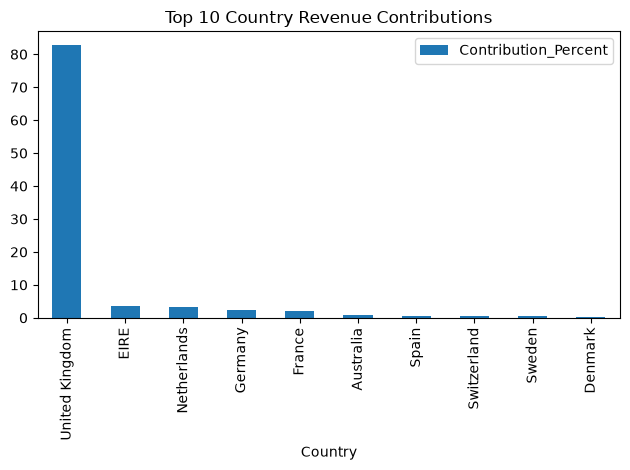

In [27]:
plt.figure(
    figsize=(10,6)
)

country_revenue.head(10).plot(
    x="Country",
    y="Contribution_Percent",
    kind="bar"
)

plt.title(
    "Top 10 Country Revenue Contributions"
)

plt.tight_layout()

plt.savefig(
    "../Images/country_ranking.png"
)

plt.show()

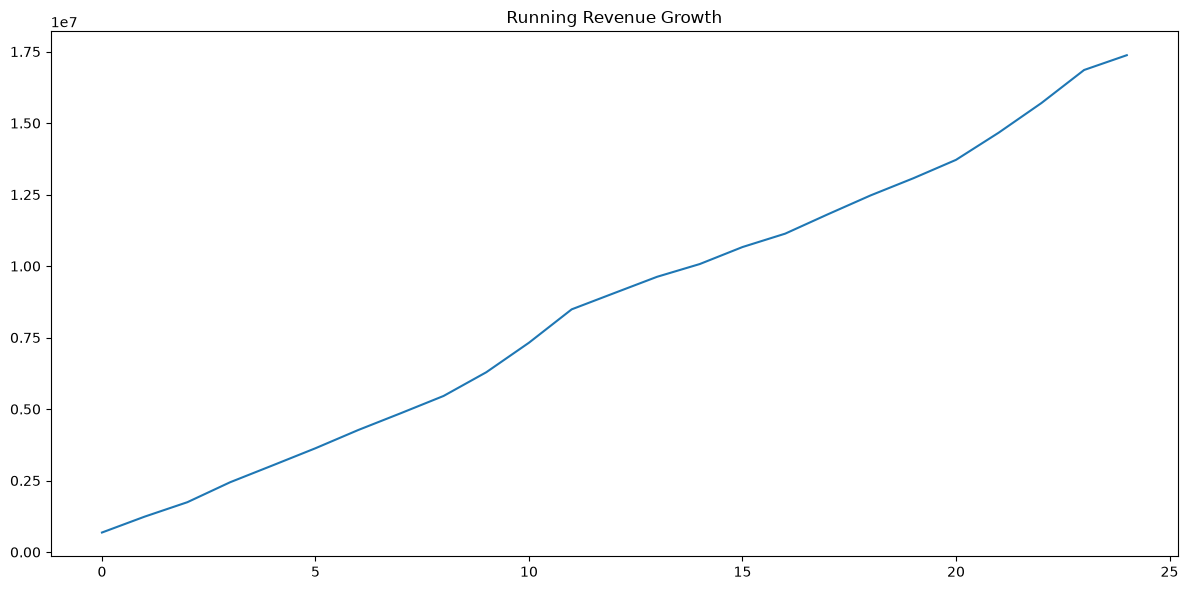

In [28]:
plt.figure(
    figsize=(12,6)
)

plt.plot(
    monthly_revenue["Running_Revenue"]
)

plt.title(
    "Running Revenue Growth"
)

plt.tight_layout()

plt.savefig(
    "../Images/running_revenue.png"
)

plt.show()

<Figure size 1200x600 with 0 Axes>

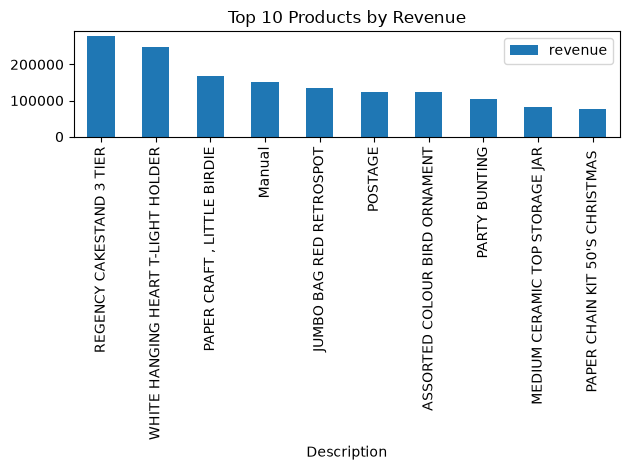

In [29]:
plt.figure(
    figsize=(12,6)
)

product_rank.head(10).plot(
    x="Description",
    y="revenue",
    kind="bar"
)

plt.title(
    "Top 10 Products by Revenue"
)

plt.tight_layout()

plt.savefig(
    "../Images/product_ranking.png"
)

plt.show()

<Figure size 1200x600 with 0 Axes>

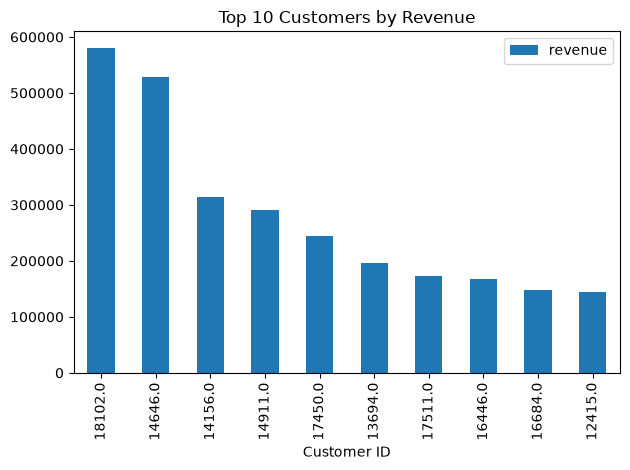

In [30]:
plt.figure(
    figsize=(12,6)
)

customer_rank.head(10).plot(
    x="Customer ID",
    y="revenue",
    kind="bar"
)

plt.title(
    "Top 10 Customers by Revenue"
)

plt.tight_layout()

plt.savefig(
    "../Images/customer_ranking.png"
)

plt.show()

In [31]:
plt.figure(
    figsize=(8,6)
)

rfm["Segment"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Customer Segments"
)

plt.xlabel(
    "Segment"
)

plt.ylabel(
    "Number of Customers"
)

plt.tight_layout()

plt.savefig(
    "../Images/rfm_segments.png"
)

plt.show()

NameError: name 'rfm' is not defined

<Figure size 800x600 with 0 Axes>

In [32]:
sql_summary = {
    "Total Revenue":
    sales_df["Revenue"].sum(),

    "Total Customers":
    sales_df["Customer ID"].nunique(),

    "Total Products":
    sales_df["Description"].nunique(),

    "Top Country":
    country_revenue.iloc[0]["Country"],

    "Top Country Contribution %":
    country_revenue.iloc[0]["Contribution_Percent"]
}

sql_summary

NameError: name 'sales_df' is not defined

In [33]:
import pandas as pd

sales_df = pd.read_csv(
    "../Dataset/clean_retail.csv"
)

In [34]:
sales_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Day
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,1


In [ ]:
sql_summary = {
    "Total Revenue":
    sales_df["Revenue"].sum(),

    "Total Customers":
    sales_df["Customer ID"].nunique(),

    "Total Products":
    sales_df["Description"].nunique(),

    "Top Country":
    country_revenue.iloc[0]["Country"],

    "Top Country Contribution %":
    country_revenue.iloc[0]["Contribution_Percent"]
}



{'Total Revenue': np.float64(17374804.268),
 'Total Customers': 5878,
 'Total Products': 5283,
 'Top Country': 'United Kingdom',
 'Top Country Contribution %': np.float64(82.81667347183493)}

In [36]:
country_revenue.head()

,Country,revenue,Contribution_Percent
38,United Kingdom,1.438923e+07,82.816673
10,EIRE,6.165705e+05,3.548647
24,Netherlands,5.540381e+05,3.188744
14,Germany,4.250197e+05,2.446184
13,France,3.487690e+05,2.007326


In [37]:
query = """
SELECT
Country,
SUM(Revenue) AS revenue
FROM retail_sales
GROUP BY Country
"""

country_revenue = pd.read_sql(
    query,
    conn
)

total_revenue = country_revenue[
    "revenue"
].sum()

country_revenue[
    "Contribution_Percent"
] = (
    country_revenue["revenue"]
    /
    total_revenue
) * 100

country_revenue = country_revenue.sort_values(
    "Contribution_Percent",
    ascending=False
)

In [38]:
sales_df.shape

(779425, 12)

In [39]:
country_revenue.head()

,Country,revenue,Contribution_Percent
38,United Kingdom,1.438923e+07,82.816673
10,EIRE,6.165705e+05,3.548647
24,Netherlands,5.540381e+05,3.188744
14,Germany,4.250197e+05,2.446184
13,France,3.487690e+05,2.007326


In [40]:
import pandas as pd

sales_df = pd.read_csv(
    "../Dataset/clean_retail.csv"
)

In [41]:
print(
    "Total Revenue:",
    sales_df["Revenue"].sum()
)

print(
    "Total Customers:",
    sales_df["Customer ID"].nunique()
)

print(
    "Total Products:",
    sales_df["Description"].nunique()
)

Total Revenue: 17374804.268
Total Customers: 5878
Total Products: 5283


In [42]:
sql_summary = {
    "Total Revenue":
    sales_df["Revenue"].sum(),

    "Total Customers":
    sales_df["Customer ID"].nunique(),

    "Total Products":
    sales_df["Description"].nunique(),

    "Top Country":
    "United Kingdom",

    "Top Country Contribution %":
    82.816673
}

summary_df = pd.DataFrame(
    [sql_summary]
)

summary_df

,Total Revenue,Total Customers,Total Products,Top Country,Top Country Contribution %
0,1.737480e+07,5878,5283,United Kingdom,82.816673


In [43]:
summary_df.to_csv(
    "../Dataset/sql_summary.csv",
    index=False
)

print(
    "sql_summary.csv saved successfully"
)

sql_summary.csv saved successfully
